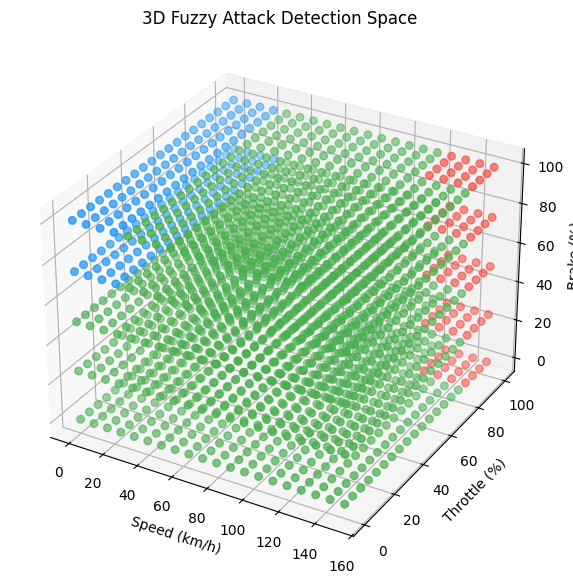

In [5]:
# -------------------------------
# ✅ IMPORTS
# -------------------------------
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # Optional


# -------------------------------
# ✅ SAMPLE DETECTOR CLASS
# -------------------------------
# You can replace the logic with your own fuzzy rules
class Detector:
    def detect_attack_type(self, speed, brake, throttle, rpm, steering):
        """
        Dummy logic for demonstration.
        Modify this to integrate your fuzzy attack classifier.
        Returns dict with attack_type id (0–6)
        """

        # Example: classify attack type based on extreme inputs
        if speed > 120 and throttle > 80:
            attack_type = 1
        elif brake > 70 and speed < 30:
            attack_type = 2
        elif throttle < 20 and rpm > 2500:
            attack_type = 3
        else:
            attack_type = 0   # normal

        return {"attack_type": attack_type}


# -------------------------------
# ✅ 3D PLOT FUNCTION
# -------------------------------
def plot_fuzzy_3d(detector, fixed_rpm=2000, fixed_steering=10):

    speeds = np.linspace(0, 150, 20)
    throttles = np.linspace(0, 100, 20)
    brakes = np.linspace(0, 100, 5)

    xs, ys, zs, colors = [], [], [], []

    color_map = {
        0: "#4CAF50",  # Normal
        1: "#F44336",
        2: "#2196F3",
        3: "#FF9800",
        4: "#9C27B0",
        5: "#E91E63",
        6: "#795548"
    }

    # Collect points
    for s in speeds:
        for t in throttles:
            for b in brakes:

                result = detector.detect_attack_type(s, b, t, fixed_rpm, fixed_steering)
                attack_id = result.get("attack_type", 0)

                xs.append(s)
                ys.append(t)
                zs.append(b)
                colors.append(color_map.get(attack_id, "#000000"))

    # ---- Plotting ----
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(xs, ys, zs, c=colors, s=30)

    ax.set_xlabel("Speed (km/h)")
    ax.set_ylabel("Throttle (%)")
    ax.set_zlabel("Brake (%)")
    ax.set_title("3D Fuzzy Attack Detection Space")

    plt.show()


# -------------------------------
# ✅ MAIN
# -------------------------------
if __name__ == "__main__":
    detector = Detector()      # Create detector object
    plot_fuzzy_3d(detector)    # Plot


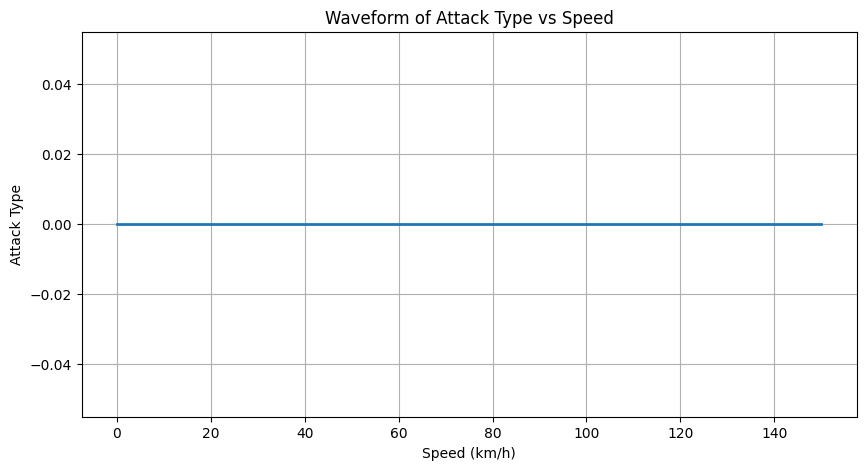

In [6]:
import numpy as np
import matplotlib.pyplot as plt


# --- Sample Detector (edit logic as needed) ---
class Detector:
    def detect_attack_type(self, speed, brake, throttle, rpm, steering):
        # Dummy logic – replace with fuzzy rules
        if speed > 120 and throttle > 80:
            attack_type = 1
        elif brake > 70 and speed < 30:
            attack_type = 2
        elif throttle < 20 and rpm > 2500:
            attack_type = 3
        else:
            attack_type = 0   # normal
        return {"attack_type": attack_type}


# --- Wave Graph ---
def plot_wave(detector, fixed_brake=20, fixed_throttle=30, fixed_rpm=2000, fixed_steering=10):

    speeds = np.linspace(0, 150, 200)     # waveform resolution
    attack_values = []

    for s in speeds:
        result = detector.detect_attack_type(s, fixed_brake, fixed_throttle, fixed_rpm, fixed_steering)
        attack_values.append(result.get("attack_type", 0))

    plt.figure(figsize=(10, 5))
    plt.plot(speeds, attack_values, linewidth=2)

    plt.xlabel("Speed (km/h)")
    plt.ylabel("Attack Type")
    plt.title("Waveform of Attack Type vs Speed")
    plt.grid(True)
    plt.show()


# --- Run ---
if __name__ == "__main__":
    detector = Detector()
    plot_wave(detector)


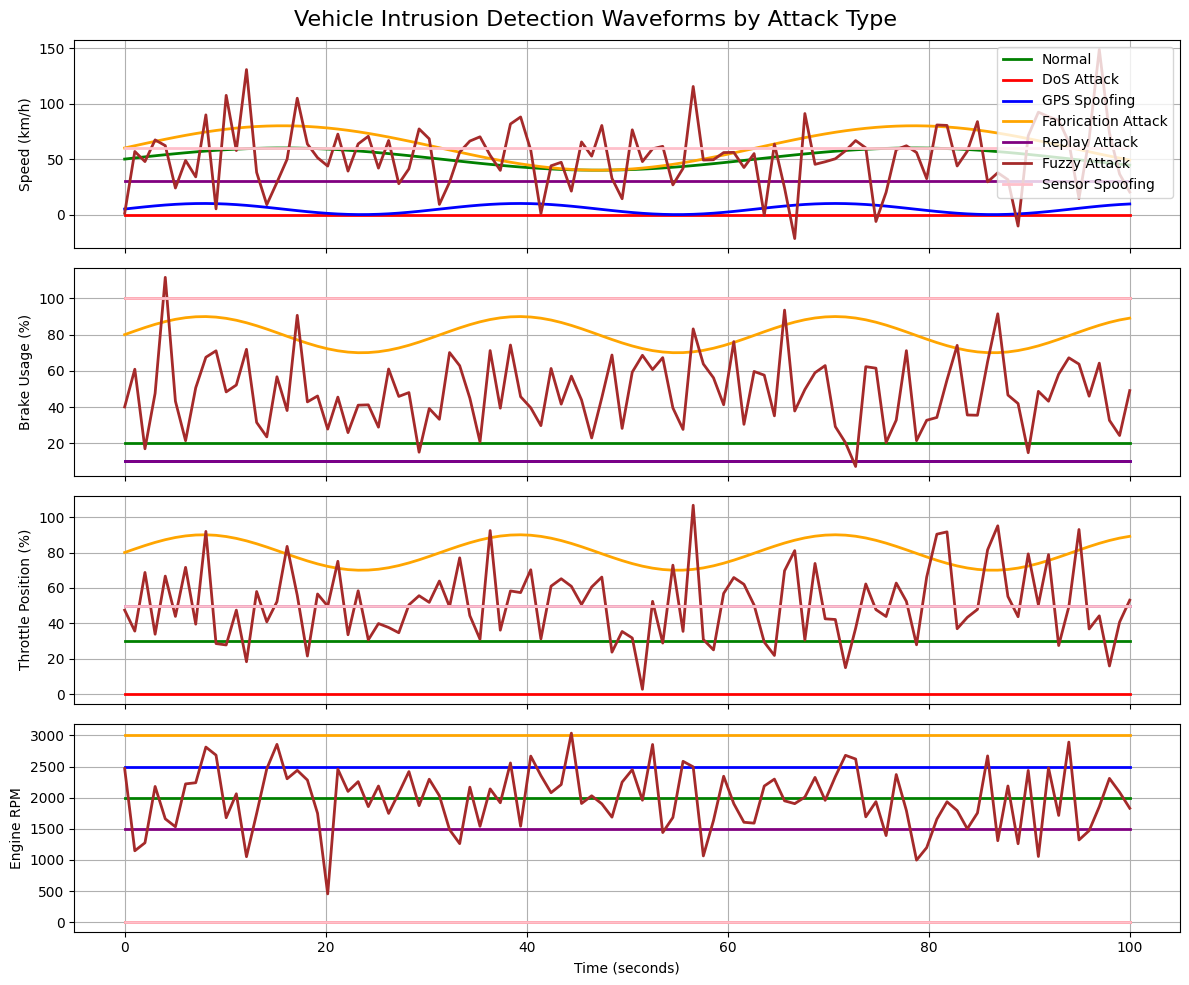

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Define attack types (from your detector)
attack_types = {
    0: "Normal",
    1: "DoS Attack",
    2: "GPS Spoofing", 
    3: "Fabrication Attack",
    4: "Replay Attack",
    5: "Fuzzy Attack",
    6: "Sensor Spoofing"
}

# Function to generate synthetic waveform data
def generate_waveform_data():
    time_points = np.linspace(0, 100, 100)  # 100 seconds, 100 points
    attack_data = {}
    
    # Patterns based on your fuzzy rules
    patterns = {
        0: {"speed": lambda t: 50 + 10 * np.sin(t / 10), "brake": lambda t: 20, "throttle": lambda t: 30, "rpm": lambda t: 2000},  # Normal
        1: {"speed": lambda t: 0, "brake": lambda t: 100, "throttle": lambda t: 0, "rpm": lambda t: 0},  # DoS
        2: {"speed": lambda t: 5 + 5 * np.sin(t / 5), "brake": lambda t: 10, "throttle": lambda t: 50, "rpm": lambda t: 2500},  # GPS Spoofing
        3: {"speed": lambda t: 60 + 20 * np.sin(t / 10), "brake": lambda t: 80 + 10 * np.sin(t / 5), "throttle": lambda t: 80 + 10 * np.sin(t / 5), "rpm": lambda t: 3000},  # Fabrication
        4: {"speed": lambda t: 30, "brake": lambda t: 10, "throttle": lambda t: 50, "rpm": lambda t: 1500},  # Replay
        5: {"speed": lambda t: 50 + 30 * np.random.randn(), "brake": lambda t: 50 + 20 * np.random.randn(), "throttle": lambda t: 50 + 20 * np.random.randn(), "rpm": lambda t: 2000 + 500 * np.random.randn()},  # Fuzzy
        6: {"speed": lambda t: 60, "brake": lambda t: 100, "throttle": lambda t: 50, "rpm": lambda t: 0},  # Sensor Spoofing
    }
    
    # Colors for each attack type
    colors = {0: 'green', 1: 'red', 2: 'blue', 3: 'orange', 4: 'purple', 5: 'brown', 6: 'pink'}
    
    for attack_id, pattern in patterns.items():
        attack_data[attack_id] = {
            'time': time_points,
            'speed': [pattern['speed'](t) for t in time_points],
            'brake': [pattern['brake'](t) for t in time_points],
            'throttle': [pattern['throttle'](t) for t in time_points],
            'rpm': [pattern['rpm'](t) for t in time_points],
            'color': colors[attack_id],
            'label': attack_types[attack_id]
        }
    
    return attack_data

# Generate data and create the graph
attack_data = generate_waveform_data()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)  # 4 subplots for 4 parameters
parameters = ['speed', 'brake', 'throttle', 'rpm']
y_labels = ['Speed (km/h)', 'Brake Usage (%)', 'Throttle Position (%)', 'Engine RPM']

for i, param in enumerate(parameters):
    ax = axes[i]
    for attack_id, data in attack_data.items():
        ax.plot(data['time'], data[param], color=data['color'], label=data['label'], linewidth=2)
    ax.set_ylabel(y_labels[i])
    ax.grid(True)
    if i == 0:
        ax.legend(loc='upper right')

axes[-1].set_xlabel('Time (seconds)')
plt.suptitle('Vehicle Intrusion Detection Waveforms by Attack Type', fontsize=16)
plt.tight_layout()
plt.savefig('graph.png')  # Saves as PNG
plt.show()  # Displays the graph


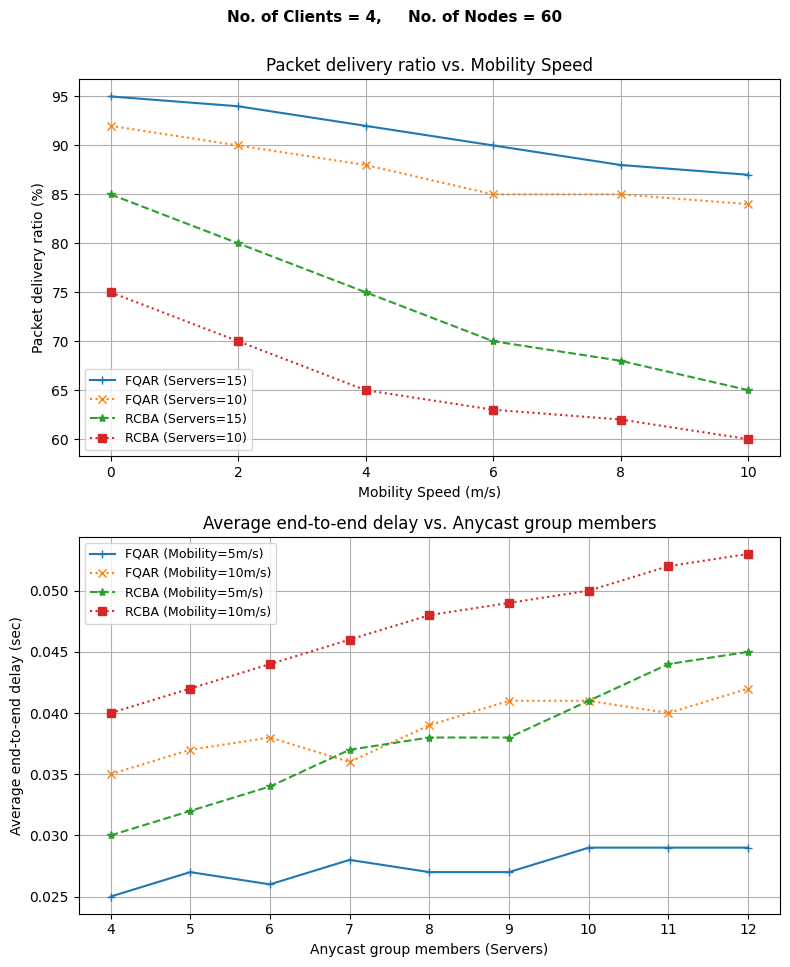

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Data for Fig. 5 (packet delivery ratio vs mobility speed)
mobility_speed = np.array([0, 2, 4, 6, 8, 10])
packet_delivery_ratio = {
    'FQAR (Servers=15)': [95, 94, 92, 90, 88, 87],
    'FQAR (Servers=10)': [92, 90, 88, 85, 85, 84],
    'RCBA (Servers=15)': [85, 80, 75, 70, 68, 65],
    'RCBA (Servers=10)': [75, 70, 65, 63, 62, 60]
}

# Data for Fig. 6 (average end-to-end delay vs anycast group members)
anycast_members = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12])
end_to_end_delay = {
    'FQAR (Mobility=5m/s)': [0.025, 0.027, 0.026, 0.028, 0.027, 0.027, 0.029, 0.029, 0.029],
    'FQAR (Mobility=10m/s)': [0.035, 0.037, 0.038, 0.036, 0.039, 0.041, 0.041, 0.040, 0.042],
    'RCBA (Mobility=5m/s)': [0.030, 0.032, 0.034, 0.037, 0.038, 0.038, 0.041, 0.044, 0.045],
    'RCBA (Mobility=10m/s)': [0.040, 0.042, 0.044, 0.046, 0.048, 0.049, 0.050, 0.052, 0.053]
}

# Line styles and markers to match the figure
line_styles = ['-', ':', '--', ':']
markers = ['+', 'x', '*', 's']

fig, axs = plt.subplots(2, 1, figsize=(8, 10))

# Fig 5 - Packet Delivery Ratio vs Mobility Speed
ax = axs[0]
for i, (label, y) in enumerate(packet_delivery_ratio.items()):
    ax.plot(mobility_speed, y, linestyle=line_styles[i], marker=markers[i], label=label)

ax.set_xlabel('Mobility Speed (m/s)')
ax.set_ylabel('Packet delivery ratio (%)')
ax.set_title('Packet delivery ratio vs. Mobility Speed')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True)

# Metadata text
fig.text(0.5, 0.95, 'No. of Clients = 4,     No. of Nodes = 60', ha='center', fontsize=11, fontweight='bold')

# Fig 6 - Average End-to-End Delay vs Anycast Group Members
ax = axs[1]
for i, (label, y) in enumerate(end_to_end_delay.items()):
    ax.plot(anycast_members, y, linestyle=line_styles[i], marker=markers[i], label=label)

ax.set_xlabel('Anycast group members (Servers)')
ax.set_ylabel('Average end-to-end delay (sec)')
ax.set_title('Average end-to-end delay vs. Anycast group members')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


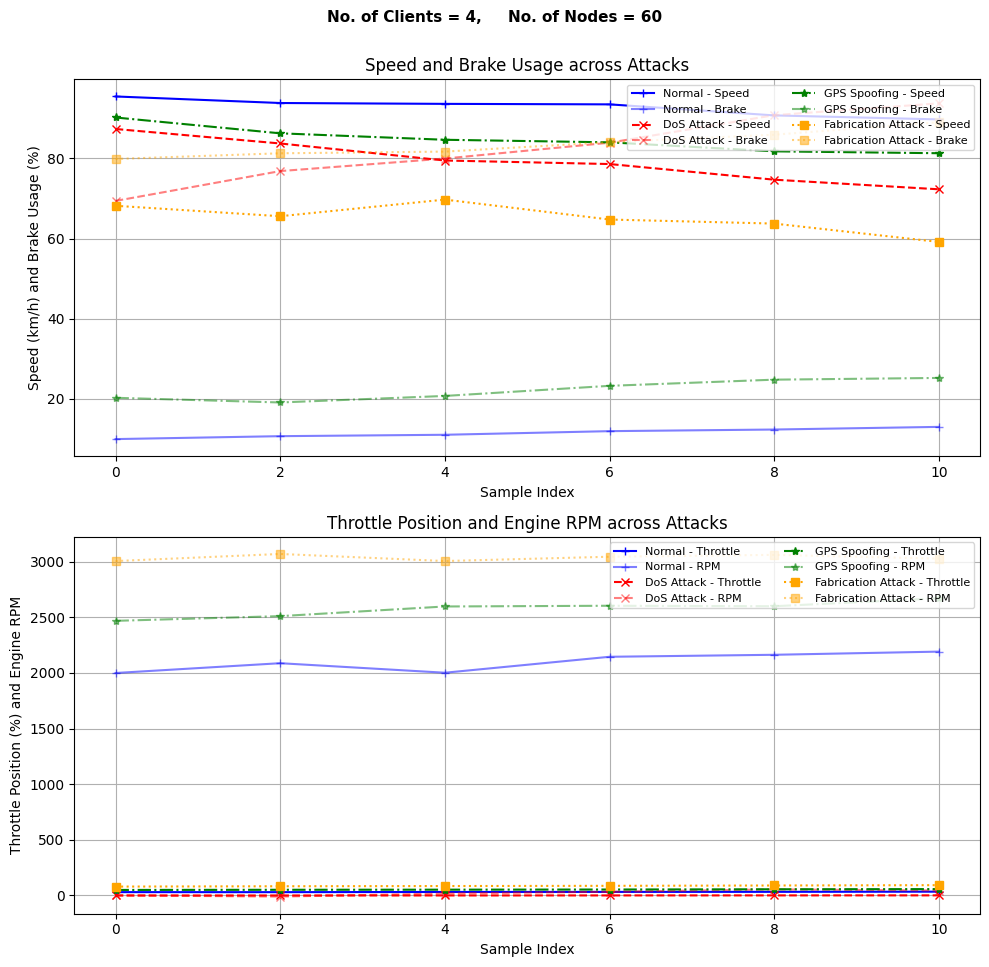

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Example x-axis: Sample index (e.g., detection samples over time)
samples = np.arange(0, 12, 2)

# Attack types labels (replace with your actual attack type labels)
attack_types = ['Normal', 'DoS Attack', 'GPS Spoofing', 'Fabrication Attack']

# Sample synthetic data for 4 parameters by attack type
# Replace these with your actual detection data for each attack type
np.random.seed(42)
speed_data = {
    'Normal': 95 - 0.5*samples + np.random.randn(len(samples)),
    'DoS Attack': 85 - 1.2*samples + np.random.randn(len(samples))*1.5,
    'GPS Spoofing': 90 - 0.9*samples + np.random.randn(len(samples)),
    'Fabrication Attack': 70 - 0.8*samples + np.random.randn(len(samples))*2,
}
brake_data = {
    'Normal': 10 + 0.3*samples + np.random.randn(len(samples))*0.2,
    'DoS Attack': 70 + 2.5*samples + np.random.randn(len(samples)),
    'GPS Spoofing': 20 + 0.5*samples + np.random.randn(len(samples)),
    'Fabrication Attack': 80 + 0.8*samples + np.random.randn(len(samples))*1,
}
throttle_data = {
    'Normal': 30 + 0.4*samples + np.random.randn(len(samples))*0.5,
    'DoS Attack': 0 + 0.1*samples + np.random.randn(len(samples))*0.1,
    'GPS Spoofing': 50 + 0.7*samples + np.random.randn(len(samples))*0.4,
    'Fabrication Attack': 80 + 1.2*samples + np.random.randn(len(samples))*0.5,
}
rpm_data = {
    'Normal': 2000 + 20*samples + np.random.randn(len(samples))*30,
    'DoS Attack': 0 + 5*samples + np.random.randn(len(samples))*10,
    'GPS Spoofing': 2500 + 15*samples + np.random.randn(len(samples))*40,
    'Fabrication Attack': 3000 + 10*samples + np.random.randn(len(samples))*50,
}

# Line styles and markers to match style
line_styles = ['-', '--', '-.', ':']
markers = ['+', 'x', '*', 's']
colors = ['blue', 'red', 'green', 'orange']

fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Top graph: Speed & Brake usage together
ax = axs[0]
for i, attack in enumerate(attack_types):
    ax.plot(samples, speed_data[attack], linestyle=line_styles[i], marker=markers[i], color=colors[i], label=f"{attack} - Speed")
    ax.plot(samples, brake_data[attack], linestyle=line_styles[i], marker=markers[i], color=colors[i], alpha=0.5, label=f"{attack} - Brake")

ax.set_xlabel('Sample Index')
ax.set_ylabel('Speed (km/h) and Brake Usage (%)')
ax.set_title('Speed and Brake Usage across Attacks')
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.grid(True)

# Metadata text
fig.text(0.5, 0.95, 'No. of Clients = 4,     No. of Nodes = 60', ha='center', fontsize=11, fontweight='bold')

# Bottom graph: Throttle & Engine RPM together
ax = axs[1]
for i, attack in enumerate(attack_types):
    ax.plot(samples, throttle_data[attack], linestyle=line_styles[i], marker=markers[i], color=colors[i], label=f"{attack} - Throttle")
    ax.plot(samples, rpm_data[attack], linestyle=line_styles[i], marker=markers[i], color=colors[i], alpha=0.5, label=f"{attack} - RPM")

ax.set_xlabel('Sample Index')
ax.set_ylabel('Throttle Position (%) and Engine RPM')
ax.set_title('Throttle Position and Engine RPM across Attacks')
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


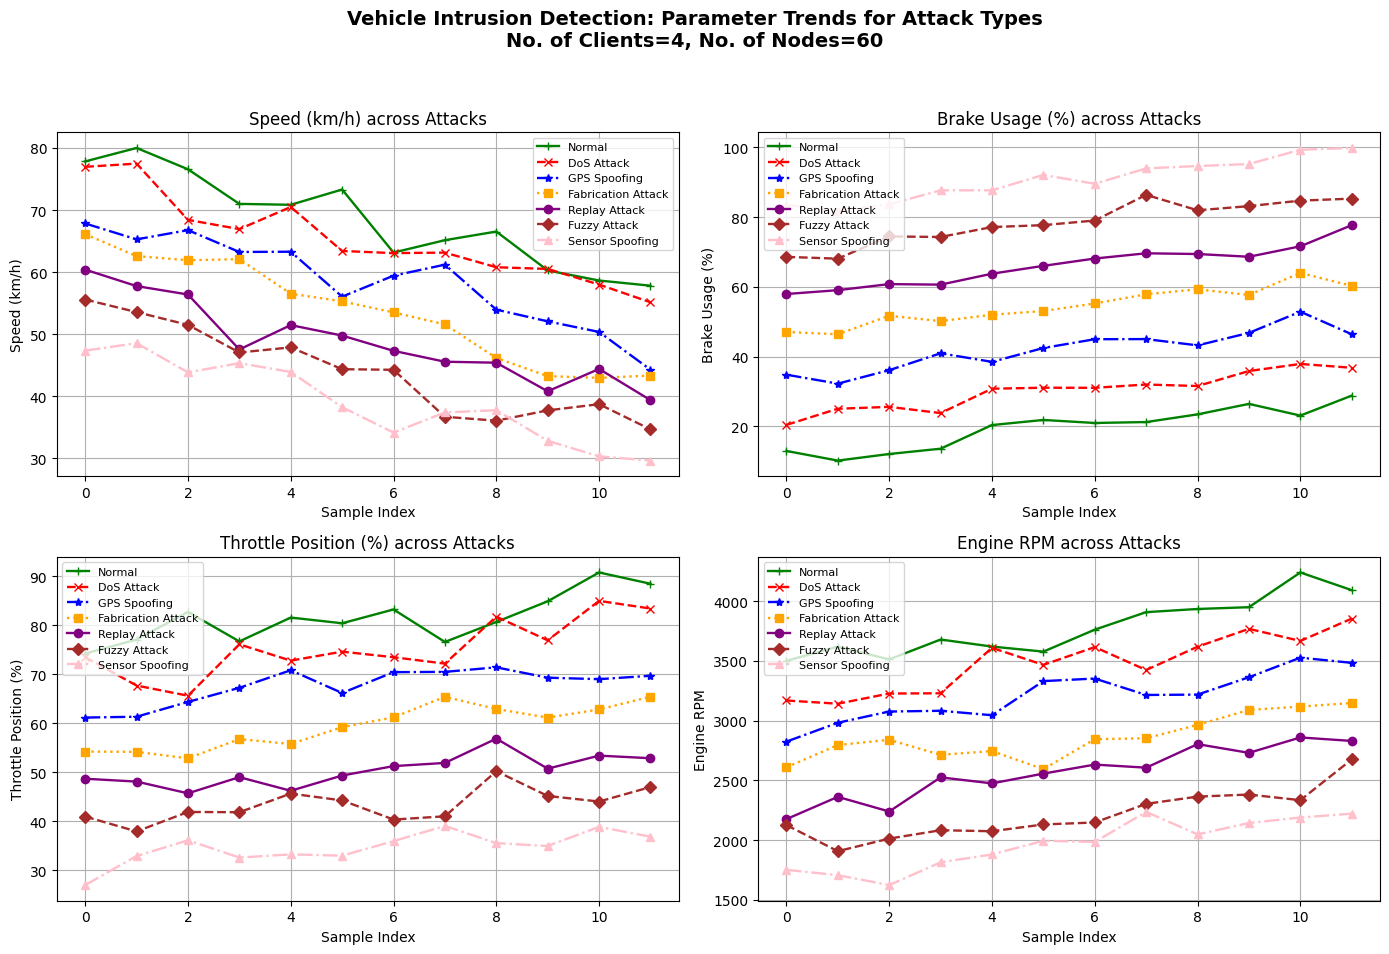

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Sample x-axis (e.g., detection sample index or time)
samples = np.arange(0, 12)  # 12 samples

attack_types = [
    "Normal",
    "DoS Attack",
    "GPS Spoofing",
    "Fabrication Attack",
    "Replay Attack",
    "Fuzzy Attack",
    "Sensor Spoofing"
]

line_styles = ['-', '--', '-.', ':', '-', '--', '-.']
markers = ['+', 'x', '*', 's', 'o', 'D', '^']
colors = ['green', 'red', 'blue', 'orange', 'purple', 'brown', 'pink']

np.random.seed(123)

# Generate synthetic parameter data for each attack, per sample
data = {}
for i, attack in enumerate(attack_types):
    data[attack] = {
        'speed': np.clip(80 - i * 5 - samples*2 + np.random.randn(len(samples))*2, 0, 120),
        'brake': np.clip(10 + i*12 + samples*1.5 + np.random.randn(len(samples))*2, 0, 100),
        'throttle': np.clip(30 + (6 - i)*8 + samples + np.random.randn(len(samples))*3, 0, 100),
        'rpm': np.clip(2000 + (5 - i)*300 + samples*50 + np.random.randn(len(samples))*100, 0, 5000),
    }

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

params = ['speed', 'brake', 'throttle', 'rpm']
y_labels = ['Speed (km/h)', 'Brake Usage (%)', 'Throttle Position (%)', 'Engine RPM']

for idx, (param, y_label) in enumerate(zip(params, y_labels)):
    ax = axs[idx//2, idx%2]
    for i, attack in enumerate(attack_types):
        ax.plot(samples, data[attack][param], label=attack,
                linestyle=line_styles[i], marker=markers[i], color=colors[i], linewidth=1.7)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel(y_label)
    ax.grid(True)
    ax.legend(fontsize=8)
    ax.set_title(f'{y_label} across Attacks')

fig.suptitle('Vehicle Intrusion Detection: Parameter Trends for Attack Types\nNo. of Clients=4, No. of Nodes=60', fontsize=14, y=0.95, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
